In [74]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [118]:
#xd = xr.open_dataset("/Users/pp/data/Simulations/A08_Hydraulics_standalone/Relative_Hypercube_sampling/Sens_Output_6_peak_rm.nc")
#df = pd.read_csv("/Users/pp/data/Simulations/A08_Hydraulics_standalone/Relative_Hypercube_sampling/setups/Full_Parameter_setup_hyperfixed_1000000.csv")
rp = '/Users/pp/data/Simulations/PHS_GFO'
xd = xr.open_dataset(f"{rp}/Sens_Output_agg.nc")
df = pd.read_csv(f"{rp}/SwissParameterListWide_24_1000000.csv")

In [92]:
rt_path = "out"
os.mkdir(rt_path)

FileExistsError: [Errno 17] File exists: 'out'

In [93]:
df

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,sustain_xylem_damage,root_area_index,...,theta_s,camp_b,psi_soil_sat,pore_size_ind,solver_precision,tree_density,sigma_log_likelyhood,soil_profile_index,soil_water_model_type_enum,stem_flow_type_enum
0,0,-1,1800.0,1800,False,1.0,4.0,Weibull,False,14.791561,...,0.52900414;0.52900414;0.52900414,6.59514415;6.59514415;6.59514415,-1.73677256;-1.73677256;-1.73677256,0.5;0.5;0.5,1.000000e-10,0.01,1.0,7,Soil_Water_Model_Type.Campbell,Stem_Flow_Model_Type.Linear
1,1,-1,1800.0,1800,False,1.0,4.0,Weibull,False,9.793321,...,0.51984105;0.51984105;0.51984105,6.5524418;6.5524418;6.5524418,-0.63279983;-0.63279983;-0.63279983,0.5;0.5;0.5,1.000000e-10,0.01,1.0,0,Soil_Water_Model_Type.Campbell,Stem_Flow_Model_Type.Linear
2,2,-1,1800.0,1800,False,1.0,4.0,Weibull,False,10.659139,...,0.4681896;0.4681896;0.4681896,8.43723926;8.43723926;8.43723926,-1.50028392;-1.50028392;-1.50028392,0.5;0.5;0.5,1.000000e-10,0.01,1.0,2,Soil_Water_Model_Type.Campbell,Stem_Flow_Model_Type.Linear
3,3,-1,1800.0,1800,False,1.0,4.0,Weibull,False,9.711660,...,0.54032475;0.54032475;0.54032475,8.92667418;8.92667418;8.92667418,-0.02212241;-0.02212241;-0.02212241,0.5;0.5;0.5,1.000000e-10,0.01,1.0,7,Soil_Water_Model_Type.Campbell,Stem_Flow_Model_Type.Linear
4,4,-1,1800.0,1800,False,1.0,4.0,Weibull,False,15.864207,...,0.48701537;0.48701537;0.48701537,6.24137362;6.24137362;6.24137362,-1.09187216;-1.09187216;-1.09187216,0.5;0.5;0.5,1.000000e-10,0.01,1.0,7,Soil_Water_Model_Type.Campbell,Stem_Flow_Model_Type.Linear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999995,-1,1800.0,1800,False,1.0,4.0,Weibull,False,15.163847,...,0.51492457;0.51492457;0.51492457,9.0938264;9.0938264;9.0938264,-0.66784565;-0.66784565;-0.66784565,0.5;0.5;0.5,1.000000e-10,0.01,1.0,6,Soil_Water_Model_Type.Campbell,Stem_Flow_Model_Type.Linear
999996,999996,-1,1800.0,1800,False,1.0,4.0,Weibull,False,19.587919,...,0.50822249;0.50822249;0.50822249,7.12027876;7.12027876;7.12027876,-1.07786946;-1.07786946;-1.07786946,0.5;0.5;0.5,1.000000e-10,0.01,1.0,4,Soil_Water_Model_Type.Campbell,Stem_Flow_Model_Type.Linear
999997,999997,-1,1800.0,1800,False,1.0,4.0,Weibull,False,19.974299,...,0.47774457;0.47774457;0.47774457,7.66997714;7.66997714;7.66997714,-1.53894023;-1.53894023;-1.53894023,0.5;0.5;0.5,1.000000e-10,0.01,1.0,6,Soil_Water_Model_Type.Campbell,Stem_Flow_Model_Type.Linear
999998,999998,-1,1800.0,1800,False,1.0,4.0,Weibull,False,11.474861,...,0.46870874;0.46870874;0.46870874,6.74317189;6.74317189;6.74317189,-0.56581933;-0.56581933;-0.56581933,0.5;0.5;0.5,1.000000e-10,0.01,1.0,6,Soil_Water_Model_Type.Campbell,Stem_Flow_Model_Type.Linear


In [109]:
df['psi_soil_sat'].str.split(';', expand=True).values[:,0]

array([-1.73677256, -0.63279983, -1.50028392, ..., -1.53894023,
       -0.56581933, -0.19994487])

In [111]:
df['psi_soil_sat0'] = df['psi_soil_sat'].str.split(';', expand=True).values[:,0].astype(float)
df['k_soil_sat0'] = df['k_soil_sats'].str.split(';', expand=True).values[:,0].astype(float)
df['camp_b0'] = df['camp_b'].str.split(';', expand=True).values[:,0].astype(float)
df['theta_s0'] = df['theta_s'].str.split(';', expand=True).values[:,0].astype(float)

In [112]:
xd

<xarray.Dataset> Size: 64MB
Dimensions:           (run_id: 1000000, tree_rmse_id: 14)
Coordinates:
  * run_id            (run_id) int64 8MB 0 1 2 3 4 ... 7807 7808 7809 7810 7811
  * tree_rmse_id      (tree_rmse_id) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    RMSE_swiss_trees  (run_id, tree_rmse_id) float32 56MB 3.007 1.83 ... 2.08

In [96]:
df_rmse = xd.data_vars['RMSE_swiss_trees'].to_pandas()
#df_rmse.reset_index(drop=True, inplace=True)

In [113]:
df_rmse

tree_rmse_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,3.006761,1.830349,6.371010,2.607850,1.933308,1.686533,2.907073,3.439540,1.919472,1.613240,2.027093,1.951650,2.085417,2.054368
1,1.520779,0.534556,4.244216,1.015906,0.606521,0.806084,1.699713,1.993295,0.941892,0.809968,0.555411,0.511312,0.557782,0.540049
2,2.657063,1.438049,5.965533,2.236760,1.548311,1.314546,2.587026,3.103948,1.566246,1.238341,1.639072,1.560336,1.697407,1.665367
3,2.982111,1.803019,6.342956,2.581842,1.906398,1.660291,2.884237,3.415833,1.894360,1.586818,2.000023,1.924387,2.058355,2.027246
4,2.975984,1.796218,6.335971,2.575374,1.899703,1.653767,2.878567,3.409941,1.888121,1.580248,1.993289,1.917603,2.051621,2.020498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,3.024544,1.850038,6.391207,2.626601,1.952702,1.705462,2.923569,3.456648,1.937602,1.632297,2.046598,1.971292,2.104917,2.073910
999996,2.983214,1.804242,6.344212,2.583006,1.907602,1.661465,2.885258,3.416893,1.895483,1.588000,2.001235,1.925608,2.059566,2.028461
999997,2.987762,1.809288,6.349393,2.587807,1.912570,1.666308,2.889469,3.421268,1.900115,1.592876,2.006233,1.930642,2.064563,2.033468
999998,3.006181,1.829706,6.370350,2.607238,1.932675,1.685915,2.906534,3.438982,1.918881,1.612618,2.026456,1.951009,2.084780,2.053730


In [114]:
df_rmse = xd.data_vars['RMSE_swiss_trees'].to_pandas()
df_rmse.reset_index(drop=True, inplace=True)

In [115]:
df_rmse

tree_rmse_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,3.006761,1.830349,6.371010,2.607850,1.933308,1.686533,2.907073,3.439540,1.919472,1.613240,2.027093,1.951650,2.085417,2.054368
1,1.520779,0.534556,4.244216,1.015906,0.606521,0.806084,1.699713,1.993295,0.941892,0.809968,0.555411,0.511312,0.557782,0.540049
2,2.657063,1.438049,5.965533,2.236760,1.548311,1.314546,2.587026,3.103948,1.566246,1.238341,1.639072,1.560336,1.697407,1.665367
3,2.982111,1.803019,6.342956,2.581842,1.906398,1.660291,2.884237,3.415833,1.894360,1.586818,2.000023,1.924387,2.058355,2.027246
4,2.975984,1.796218,6.335971,2.575374,1.899703,1.653767,2.878567,3.409941,1.888121,1.580248,1.993289,1.917603,2.051621,2.020498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,3.024544,1.850038,6.391207,2.626601,1.952702,1.705462,2.923569,3.456648,1.937602,1.632297,2.046598,1.971292,2.104917,2.073910
999996,2.983214,1.804242,6.344212,2.583006,1.907602,1.661465,2.885258,3.416893,1.895483,1.588000,2.001235,1.925608,2.059566,2.028461
999997,2.987762,1.809288,6.349393,2.587807,1.912570,1.666308,2.889469,3.421268,1.900115,1.592876,2.006233,1.930642,2.064563,2.033468
999998,3.006181,1.829706,6.370350,2.607238,1.932675,1.685915,2.906534,3.438982,1.918881,1.612618,2.026456,1.951009,2.084780,2.053730


In [64]:
df_rmse

tree_rmse_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.914730,2.173871,2.452329,1.787036,2.133198,2.413001,2.285753,2.091680,2.356323,2.457214,2.031791,2.072294,1.982663,2.000844
1,2.481910,1.237385,5.754653,2.048922,1.352820,1.130227,2.430677,2.936393,1.393829,1.052365,1.441074,1.360105,1.499269,1.466588
2,3.013312,1.837605,6.378454,2.614759,1.940455,1.693507,2.913147,3.445842,1.926150,1.620261,2.034281,1.958889,2.092603,2.061570
3,2.032751,0.713336,5.170894,1.559971,0.850899,0.702768,2.049482,2.506914,0.996910,0.626136,0.923229,0.833679,0.978955,0.944120
4,3.029241,1.855235,6.396536,2.631551,1.957822,1.710460,2.927929,3.461167,1.942392,1.637329,2.051746,1.976476,2.110063,2.079068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3.024170,1.849624,6.390782,2.626206,1.952294,1.705063,2.923221,3.456288,1.937221,1.631896,2.046187,1.970879,2.104506,2.073499
9996,3.013617,1.837942,6.378800,2.615080,1.940787,1.693831,2.913430,3.446136,1.926461,1.620588,2.034615,1.959226,2.092937,2.061905
9997,3.009335,1.833201,6.373936,2.610565,1.936117,1.689274,2.909459,3.442017,1.922096,1.616000,2.029918,1.954495,2.088241,2.057199
9998,3.019382,1.844326,6.385348,2.621159,1.947075,1.699968,2.918779,3.451682,1.932339,1.626766,2.040938,1.965593,2.099259,2.068240


In [100]:
cols = np.array(['tab:blue' for _ in range(14)])
cols[0] = 'tab:red'
cols[2] = 'tab:red'
cols[3] = 'tab:red'
cols[6] = 'tab:red'
cols[7] = 'tab:red'

In [101]:
range_real = [0, 1, 3, 4, 6, 7, 9, 10, 11, 12, 13]

In [102]:
df_rmse

tree_rmse_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,3.006761,1.830349,6.371010,2.607850,1.933308,1.686533,2.907073,3.439540,1.919472,1.613240,2.027093,1.951650,2.085417,2.054368
1,1.520779,0.534556,4.244216,1.015906,0.606521,0.806084,1.699713,1.993295,0.941892,0.809968,0.555411,0.511312,0.557782,0.540049
2,2.657063,1.438049,5.965533,2.236760,1.548311,1.314546,2.587026,3.103948,1.566246,1.238341,1.639072,1.560336,1.697407,1.665367
3,2.982111,1.803019,6.342956,2.581842,1.906398,1.660291,2.884237,3.415833,1.894360,1.586818,2.000023,1.924387,2.058355,2.027246
4,2.975984,1.796218,6.335971,2.575374,1.899703,1.653767,2.878567,3.409941,1.888121,1.580248,1.993289,1.917603,2.051621,2.020498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,3.024544,1.850038,6.391207,2.626601,1.952702,1.705462,2.923569,3.456648,1.937602,1.632297,2.046598,1.971292,2.104917,2.073910
999996,2.983214,1.804242,6.344212,2.583006,1.907602,1.661465,2.885258,3.416893,1.895483,1.588000,2.001235,1.925608,2.059566,2.028461
999997,2.987762,1.809288,6.349393,2.587807,1.912570,1.666308,2.889469,3.421268,1.900115,1.592876,2.006233,1.930642,2.064563,2.033468
999998,3.006181,1.829706,6.370350,2.607238,1.932675,1.685915,2.906534,3.438982,1.918881,1.612618,2.026456,1.951009,2.084780,2.053730


In [116]:
for i in range_real:
    ord = df_rmse[i].nsmallest(1000)
    ind = ord.index.to_numpy()
    df_slice = df.iloc[ind]
    df_slice = df_slice.drop(columns = ['Unnamed: 0'])
    df_slice.to_csv(f"{rt_path}/Parameters_{i}.csv")

In [104]:
df_rmse[3].nsmallest(1000)

903088    0.706756
471524    0.712170
374658    0.712870
788718    0.718516
555396    0.720479
            ...   
599328    0.972793
712176    0.972793
894120    0.972793
985092    0.972793
120464    0.972793
Name: 3, Length: 1000, dtype: float32

In [117]:
vars = ['psi_leaf_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'leaf_area_index', 'g0', 'g1', 'k_soil_sat0', 'camp_b0', 'psi_soil_sat0','jackson_root_beta', 'soil_profile_index', 'theta_s0'  ]

for var in vars:
    print(var)
    fig = plt.figure(figsize= (12,12))
    i = 0
    for ti in range_real:
        #ord = df_rmse[ti].sort_values(0)[0:1000]
        ord = df_rmse[ti].nsmallest(1000)
        ind = ord.index.to_numpy()
        df_slice = df.iloc[ind]

        ax = fig.add_subplot(4,3, i + 1)
        ax.hist(df_slice[var], bins = 40, color = cols[ti])
        ax.text(0.995, 0.9, np.round(np.mean(ord),2), fontdict = None, horizontalalignment='right', verticalalignment='center', c= "black",
                            transform=ax.transAxes)
        i+=1
    #plt.show()
    plt.savefig(f"{rt_path}/{var}.png", dpi = 150, bbox_inches='tight',
                        pad_inches=0)
    plt.close()


psi_leaf_50_close
stem_hydraulic_capacitance
k_xylem_sat
huber_value
leaf_hydraulic_capacitance
leaf_area_index
g0
g1
k_soil_sat0
camp_b0
theta_s
psi_soil_sat0
jackson_root_beta
soil_profile_index
theta_s0


In [54]:
ord = df_rmse[4].nsmallest(1000)
ind = ord.index.to_numpy()
df_slice = df.iloc[ind]
df_slice[vars].describe()

,psi_leaf_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,leaf_area_index,g0,g1,jackson_root_beta,soil_profile_index
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,-1.884561,507.848538,38.402358,0.000299,1.008384,4.028484,0.064071,2.525990,0.878260,3.52200
std,0.234029,287.266769,49.426969,0.000115,0.288299,1.156968,0.020185,1.153353,0.046339,2.32571
min,-2.299339,0.755555,1.009385,0.000101,0.501024,2.000422,0.030079,0.500765,0.800057,0.00000
25%,-2.089186,259.457690,3.998272,0.000202,0.756825,3.034143,0.046888,1.515950,0.840760,2.00000
50%,-1.880608,511.842076,14.784846,0.000300,1.017095,4.028541,0.063364,2.517444,0.876585,3.00000
75%,-1.668296,752.983092,58.490320,0.000396,1.246444,5.059984,0.081205,3.515273,0.918798,6.00000
max,-1.501612,999.249600,199.658232,0.000500,1.496826,5.999737,0.099922,4.492438,0.959888,7.00000


In [29]:
df_slice.colu

Index(['Unnamed: 0', 'root_zone_depth', 'root_area_index', 'canopy_height',
       'rho_water', 'grav', 'eta_LS', 'stem_hydraulic_capacitance',
       'k_xylem_sat', 'huber_value', 'psi50_xylem', 'd_50_s',
       'leaf_hydraulic_capacitance', 'leaf_area_index', 'psi_leaf_50_close',
       'd_50_close', 'g0', 'g1', 'nsoil', 'layer_depth',
       'min_soil_layer_depth', 'max_soil_layer_depth', 'jackson_root_beta',
       'k_soil_sat', 'theta_r', 'alpha_genucht', 'n_genucht', 'neta_genucht',
       'camp_b', 'theta_s', 'camp_psi_soil_ref', 'solver_precision'],
      dtype='object')

In [30]:
np.mean(ord)

0.5765938

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_27459/2584793100.py:3: FutureWarning: In a future version of pandas all arguments of Series.sort_values will be keyword-only.
  ord = df_rmse[i].sort_values(0)


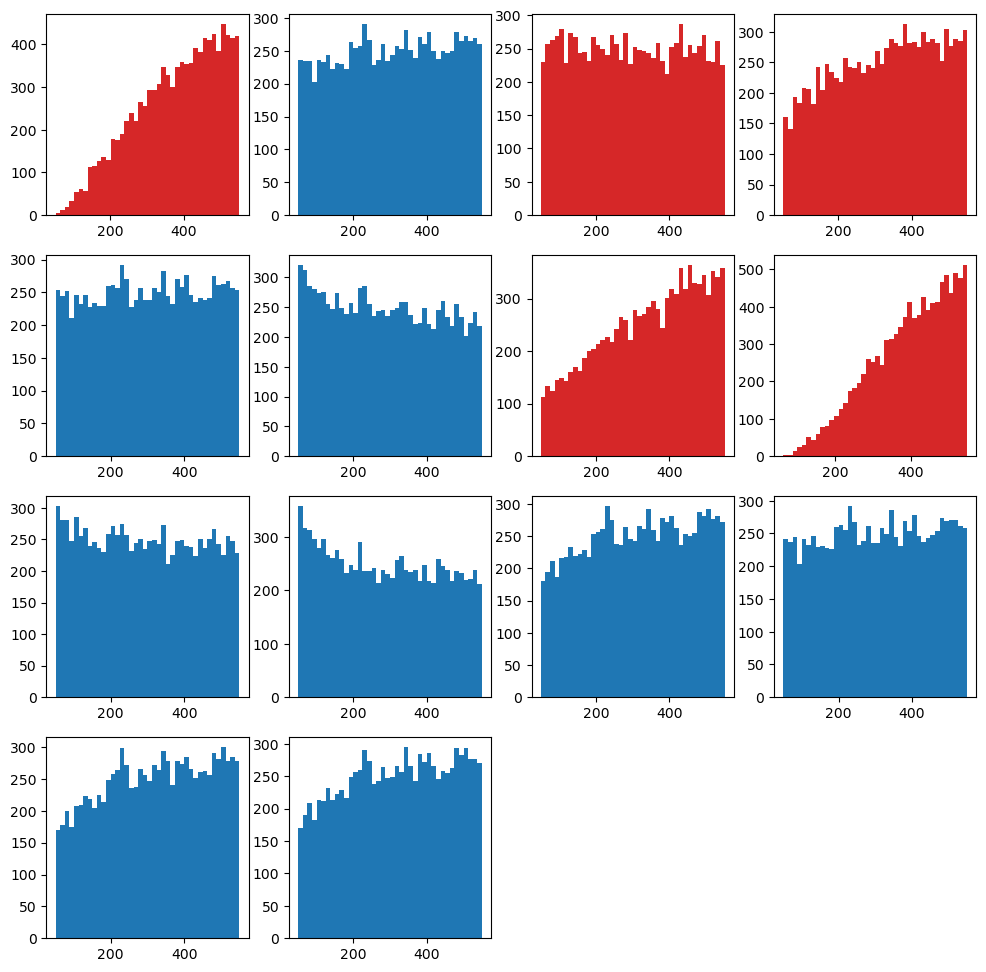

In [31]:
fig = plt.figure(figsize= (12,12))
for i in range(14):
    ord = df_rmse[i].sort_values(0)
    ind = ord.index.to_numpy()[0:10000]
    df_slice = df.iloc[ind]

    ax = fig.add_subplot(4,4, i + 1)
    ax.hist(df_slice['k_xylem_sat'], bins = 40, color = cols[i])
plt.show()

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_97211/2660022478.py:3: FutureWarning: In a future version of pandas all arguments of Series.sort_values will be keyword-only.
  ord = df_rmse[i].sort_values(0)


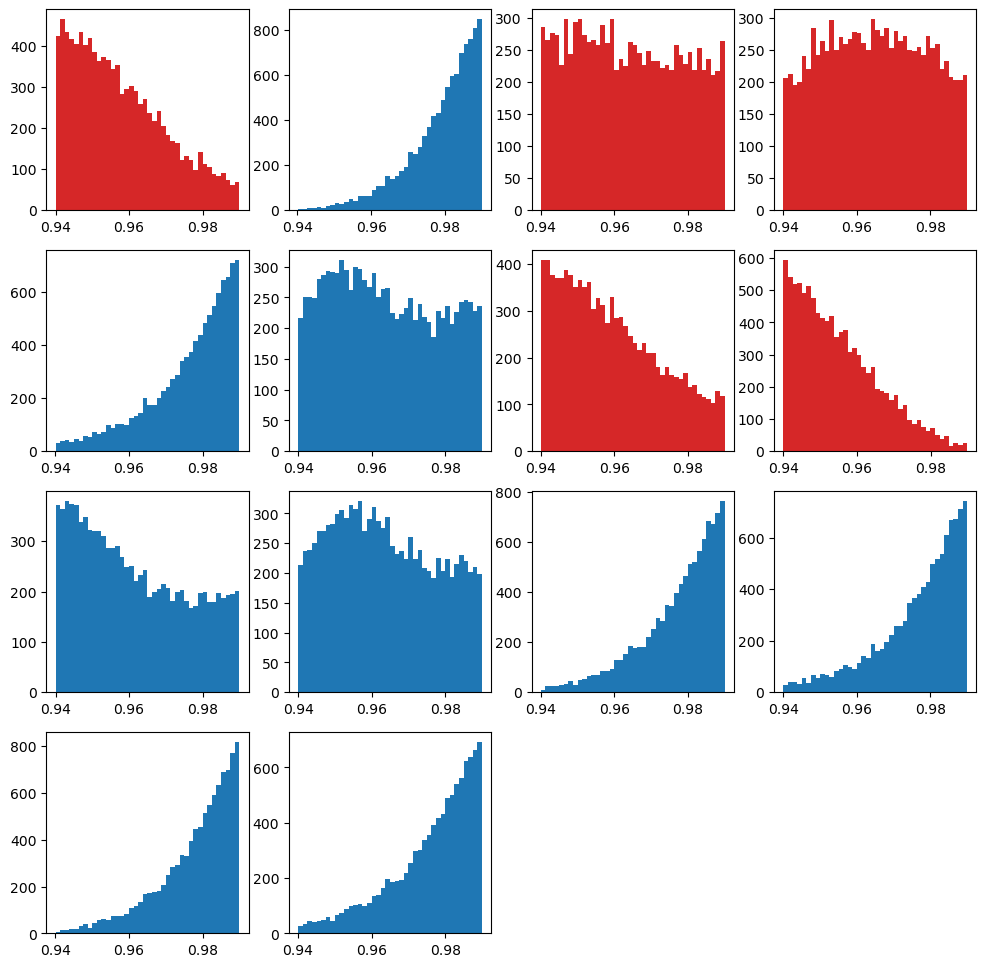

In [112]:
fig = plt.figure(figsize= (12,12))
for i in range(14):
    ord = df_rmse[i].sort_values(0)
    ind = ord.index.to_numpy()[0:10000]
    df_slice = df.iloc[ind]

    ax = fig.add_subplot(4,4, i + 1)
    ax.hist(df_slice['jackson_root_beta'], bins = 40, color = cols[i])
plt.show()

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_97211/4111008330.py:3: FutureWarning: In a future version of pandas all arguments of Series.sort_values will be keyword-only.
  ord = df_rmse[i].sort_values(0)


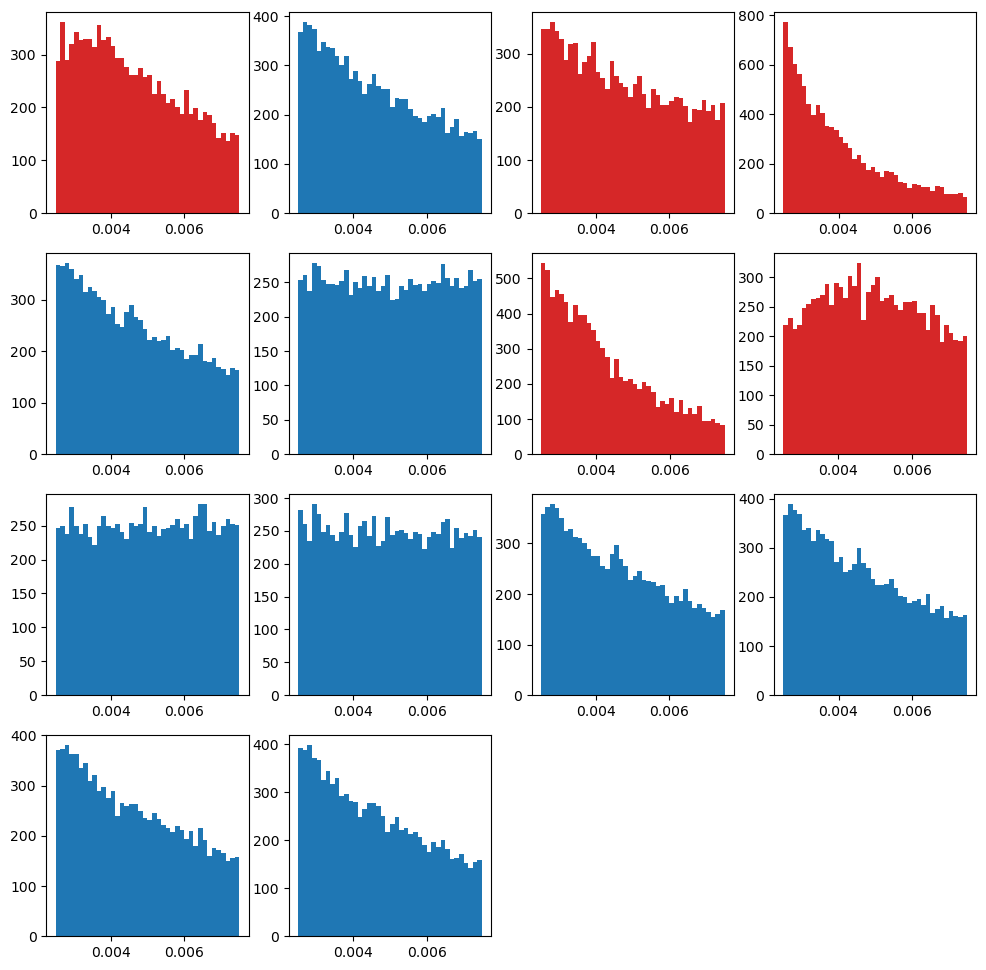

In [113]:
fig = plt.figure(figsize= (12,12))
for i in range(14):
    ord = df_rmse[i].sort_values(0)
    ind = ord.index.to_numpy()[0:10000]
    df_slice = df.iloc[ind]

    ax = fig.add_subplot(4,4, i + 1)
    ax.hist(df_slice['g0'], bins = 40, color = cols[i])
plt.show()

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_97211/2111389827.py:3: FutureWarning: In a future version of pandas all arguments of Series.sort_values will be keyword-only.
  ord = df_rmse[i].sort_values(0)


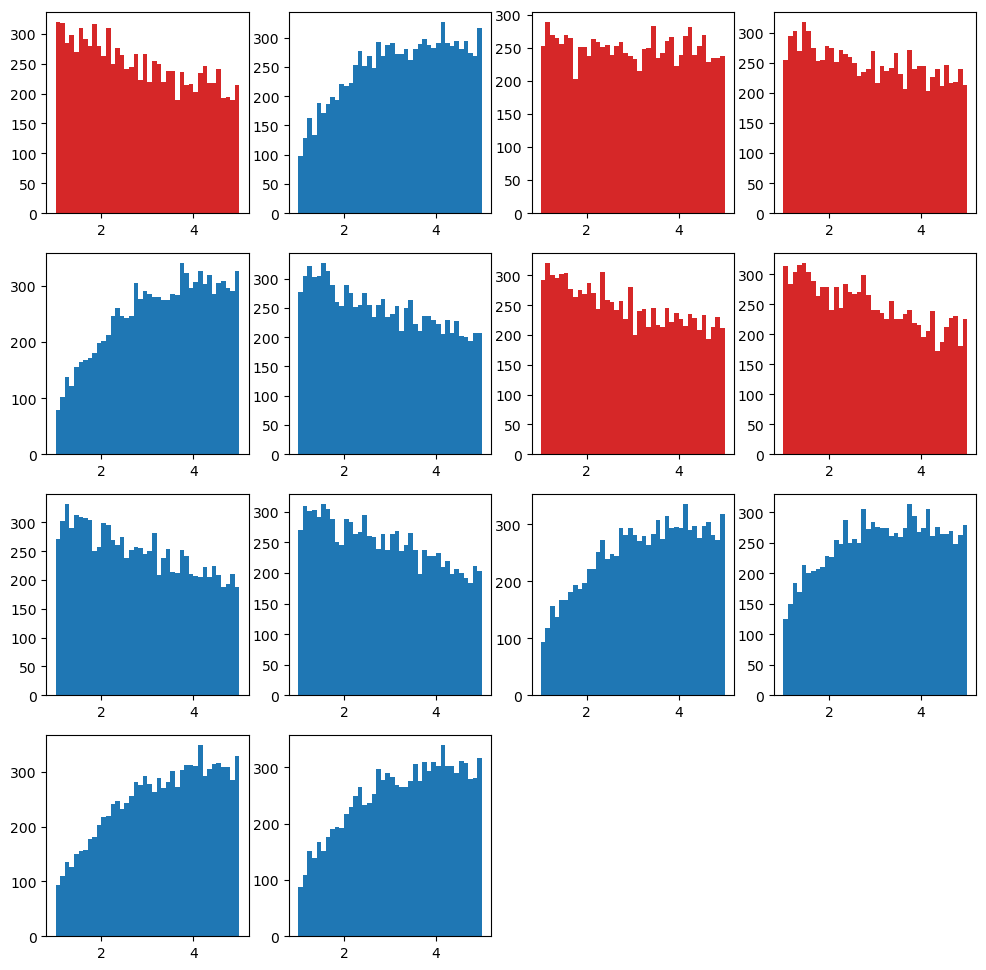

In [114]:
fig = plt.figure(figsize= (12,12))
for i in range(14):
    ord = df_rmse[i].sort_values(0)
    ind = ord.index.to_numpy()[0:10000]
    df_slice = df.iloc[ind]

    ax = fig.add_subplot(4,4, i + 1)
    ax.hist(df_slice['g1'], bins = 40, color = cols[i])
plt.show()